In [1]:
import torch
from torchvision import transforms,datasets
from torch.utils.data import DataLoader

transforming_traindata=transforms.Compose([
    transforms.Resize((48,48)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
transforming_testdata=transforms.Compose([
    transforms.Resize((48,48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5],std=[0.5])
])

traindata=datasets.ImageFolder(root='train',transform=transforming_traindata)
testdata=datasets.ImageFolder(root='test',transform=transforming_testdata)

In [2]:
trainloader=DataLoader(traindata,batch_size=64,shuffle=True,num_workers=2)
testloader=DataLoader(testdata,batch_size=64,shuffle=True,num_workers=2)

classes=traindata.classes
print("Classes:",classes)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [3]:
import torch.nn as nn
import torch.nn.functional as F
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(3,32,kernel_size=3,padding=1) 
        self.bn1=nn.BatchNorm2d(32)

        self.conv2=nn.Conv2d(32,64,kernel_size=3,padding=1)
        self.bn2=nn.BatchNorm2d(64)
        
        self.conv3=nn.Conv2d(64,128,kernel_size=3,padding=1)
        self.bn3=nn.BatchNorm2d(128)

        self.pool=nn.MaxPool2d(2,2)
        self.drop=nn.Dropout(0.3)

        self.fc1=nn.Linear(128*6*6,128) 
        self.fc2=nn.Linear(128,64)
        self.fc3=nn.Linear(64,7)

    def forward(self, x):
        x=self.pool(F.relu(self.bn1(self.conv1(x))))
        x=self.pool(F.relu(self.bn2(self.conv2(x))))
        x=self.pool(F.relu(self.bn3(self.conv3(x))))
        x=self.drop(x)

        x=torch.flatten(x,1)
        x=F.relu(self.fc1(x))
        x=self.drop(x)
        x=F.relu(self.fc2(x))
        x=self.fc3(x)
        return x
    
model=CNN()

In [4]:
import torch.optim as optim
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

print("Training")
runningloss=0.0

for epoch in range(2):
    for i,data in enumerate(trainloader,0):
        inputs,labels=data
        optimizer.zero_grad()
        outputs=model(inputs)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        
        runningloss+=loss.item()
        if i%2000==1999:
            print(f'Epoch {epoch+1}, Batch {i+1}, Loss: {runningloss}')
            runningloss=0.0

Training


In [5]:
iteration=iter(testloader)
print("Testing")
images,labels=next(iteration)
print("Classes",[classes[labels[j]] for j in range(len(labels))])

Testing
Classes ['happy', 'neutral', 'fear', 'happy', 'happy', 'happy', 'angry', 'surprise', 'neutral', 'angry', 'neutral', 'angry', 'fear', 'surprise', 'surprise', 'sad', 'angry', 'angry', 'happy', 'happy', 'neutral', 'happy', 'happy', 'happy', 'neutral', 'sad', 'surprise', 'sad', 'angry', 'happy', 'happy', 'happy', 'surprise', 'happy', 'neutral', 'sad', 'neutral', 'neutral', 'surprise', 'happy', 'sad', 'sad', 'fear', 'neutral', 'surprise', 'fear', 'surprise', 'angry', 'happy', 'happy', 'fear', 'happy', 'angry', 'angry', 'neutral', 'sad', 'surprise', 'happy', 'happy', 'neutral', 'happy', 'neutral', 'happy', 'happy']


In [6]:
outputs=model(images)
_,predicted=torch.max(outputs,1)
print("Predicted classes:",[classes[predicted[j]] for j in range(len(predicted))])

Predicted classes: ['fear', 'neutral', 'sad', 'happy', 'sad', 'happy', 'fear', 'fear', 'sad', 'fear', 'happy', 'sad', 'neutral', 'surprise', 'fear', 'angry', 'sad', 'neutral', 'angry', 'happy', 'neutral', 'happy', 'happy', 'happy', 'sad', 'sad', 'fear', 'sad', 'angry', 'happy', 'happy', 'happy', 'fear', 'happy', 'sad', 'sad', 'sad', 'neutral', 'sad', 'happy', 'neutral', 'neutral', 'happy', 'sad', 'surprise', 'fear', 'surprise', 'neutral', 'happy', 'happy', 'sad', 'happy', 'happy', 'happy', 'sad', 'sad', 'surprise', 'happy', 'happy', 'neutral', 'happy', 'neutral', 'angry', 'surprise']


In [7]:
correct=0
total=0
with torch.no_grad():
    for data in testloader:
        images,labels=data
        outputs=model(images)
        _,predicted=torch.max(outputs,1)
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()
print(f'Accuracy of model: {100*correct//total}')

Accuracy of model: 45


<Figure size 1000x700 with 0 Axes>

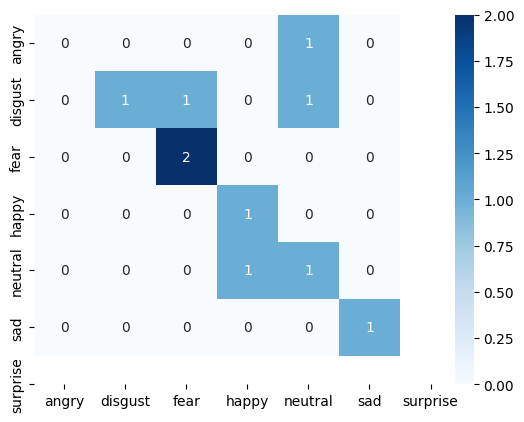

<Figure size 1000x700 with 0 Axes>

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

confusion=confusion_matrix(labels.numpy(),predicted.numpy())
sns.heatmap(confusion,cmap='Blues',xticklabels=classes, yticklabels=classes,annot=True)
plt.figure(figsize=(10,7))
